<a href="https://colab.research.google.com/github/Gnoltd/BitcoinPredictionResearch-/blob/main/%5BCRYPTO%5D_TECHNICAL_INDICATORS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title # Mount Data
from google.colab import drive
import os

# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive'):
    # Only remove if it's a directory and not already a mount point
    if os.path.isdir('/content/drive') and not os.path.ismount('/content/drive'):
        print("Clearing existing /content/drive directory...")
        for root, dirs, files in os.walk('/content/drive', topdown=False):
            for name in files:
                os.remove(os.path.join(root, name))
            for name in dirs:
                os.rmdir(os.path.join(root, name))
    elif os.path.isfile('/content/drive'):
        print("Removing file at /content/drive...")
        os.remove('/content/drive')

# Attempt to create the directory if it doesn't exist (it should be empty now)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

Clearing existing /content/drive directory...
Mounted at /content/drive


In [ ]:
# @title #CRAWL DATA
import os
import hashlib
import pandas as pd
import numpy as np
import requests
import re
import warnings
from datetime import datetime
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Reproducibility logging ─────────────────────────────────
retrieval_date = datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ')
print(f"[REPRODUCIBILITY] Data retrieval timestamp (UTC): {retrieval_date}")

# ── Directory configuration ──────────────────────────────────
base_dir = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
out_dir = os.path.join(base_dir, 'RawData')
os.makedirs(out_dir, exist_ok=True)
os.chdir(base_dir)

# ── Extended date range: 2016–2025 ───────────────────────────
start_date = '2013-01-01'
end_date   = '2025-12-31'
coin       = 'bitcoin'

# ── Features to extract ──────────────────────────────────────
raw_features_list = [
    'transactions', 'size', 'sentbyaddress', 'transactionfees',
    'blocktime', 'difficulty', 'hashrate', 'transactionvalue',
    'mediantransactionvalue', 'profitability', 'activeaddresses',
    'sentinusd', 'top100cap', 'fee-to-reward-ratio', 'mediantransactionfee'
]
# Include price as the regression target (renamed to Close below)
features_to_fetch = raw_features_list + ['price']

# ── BitInfoCharts extraction function ───────────────────────
def fetch_bitinfocharts_data(feature, coin):
    """Fetch daily metric data from BitInfoCharts and return a DataFrame
    together with a SHA-256 hash of the raw HTML for reproducibility."""
    url = f"https://bitinfocharts.com/comparison/{coin}-{feature}.html#alltime"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)

    # Reproducibility: hash raw response content
    content_hash = hashlib.sha256(response.content).hexdigest()

    pattern = r'\[new Date\("(.*?)"\),(.*?)\]'
    matches = re.findall(pattern, response.text)

    dates, values = [], []
    for match in matches:
        dates.append(pd.to_datetime(match[0]))
        val = match[1]
        values.append(float(val) if val != 'null' else np.nan)

    df = pd.DataFrame({'Date': dates, feature: values})
    df.set_index('Date', inplace=True)
    return df, content_hash

# ── Execute data fetching loop ───────────────────────────────
print(f"Fetching raw data from BitInfoCharts ({start_date} to {end_date})...")
df_raw   = pd.DataFrame()
hash_log = {}

for feature in features_to_fetch:
    try:
        df_temp, content_hash = fetch_bitinfocharts_data(feature, coin)
        hash_log[feature] = content_hash
        df_raw = df_temp if df_raw.empty else df_raw.join(df_temp, how='outer')
        print(f"  Fetched: {feature} | SHA-256: {content_hash[:16]}...")
    except Exception as e:
        print(f"  Error fetching {feature}: {e}")

# Rename 'price' → 'Close' for regression clarity
if 'price' in df_raw.columns:
    df_raw.rename(columns={'price': 'Close'}, inplace=True)

# ── Save raw data ────────────────────────────────────────────
output_filename = os.path.join(out_dir, f'{coin}_raw_data.csv')
df_raw.to_csv(output_filename)

# ── Save reproducibility log ─────────────────────────────────
repro_log = pd.DataFrame([{
    'retrieval_timestamp_utc': retrieval_date,
    'coin': coin,
    'start_date': start_date,
    'end_date': end_date,
    **{f'sha256_{k}': v for k, v in hash_log.items()}
}])
repro_log.to_csv(os.path.join(out_dir, f'{coin}_retrieval_log.csv'), index=False)

print(f"\nRaw data saved to       : {output_filename}")
print(f"Reproducibility log saved: {os.path.join(out_dir, f'{coin}_retrieval_log.csv')}")


Fetching raw data...
Successfully fetched: transactions
Successfully fetched: size
Successfully fetched: sentbyaddress
Successfully fetched: transactionfees
Successfully fetched: blocktime
Successfully fetched: difficulty
Successfully fetched: hashrate
Successfully fetched: transactionvalue
Successfully fetched: mediantransactionvalue
Successfully fetched: profitability
Successfully fetched: activeaddresses
Successfully fetched: sentinusd
Successfully fetched: top100cap
Successfully fetched: fee-to-reward-ratio
Successfully fetched: mediantransactionfee
Successfully fetched: price
Process completed. Raw data saved to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/RawData/bitcoin_raw_data.csv


In [ ]:
# @title #SPLIT TRAIN/TEST
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
start_date = '2013-01-01'   # Extended to 2016
end_date   = '2025-12-31'
coin       = 'bitcoin'

base_dir      = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
raw_data_file = os.path.join(base_dir, 'RawData/bitcoin_raw_data.csv')
output_dir    = os.path.join(base_dir, 'RawData')
os.makedirs(output_dir, exist_ok=True)

# ── Load and reindex to continuous daily range ───────────────
print("Loading continuous raw data...")
df_raw          = pd.read_csv(raw_data_file, index_col=0, parse_dates=True)
full_date_range = pd.date_range(start=start_date, end=end_date, freq='D')
df_raw          = df_raw.reindex(full_date_range)
df_raw.index.name = 'Date'

print(f"Full data shape : {df_raw.shape}")
print(f"Date range      : {df_raw.index.min()} to {df_raw.index.max()}")

# ── Export continuous data ───────────────────────────────────
full_data_file = os.path.join(output_dir, f'{coin}_full_raw.csv')
df_raw.to_csv(full_data_file)
print(f"Continuous raw data exported to: {full_data_file}")


Loading continuous raw data...
Full data shape: (1096, 16)
Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Continuous raw data exported to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/RawData/bitcoin_full_raw.csv


In [ ]:
# PRE-PROCESSING ON FULL DATASET (TRAIN-FIT ONLY)
# Target: Close price (regression) — NOT log returns
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pywt
import pickle

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin        = 'bitcoin'
train_start = '2013-01-01'   # Extended to 2016
train_end   = '2023-12-31'   # ~80 % of 2016-2025 used for training
base_dir    = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
raw_file    = os.path.join(base_dir, 'RawData', f'{coin}_full_raw.csv')
processed_dir = os.path.join(base_dir, 'ProcessedData')
os.makedirs(processed_dir, exist_ok=True)

# ── Load data ────────────────────────────────────────────────
df_full = pd.read_csv(raw_file, index_col='Date', parse_dates=True)

# Ensure 'Close' column exists (may have been saved as 'price' on older runs)
if 'price' in df_full.columns and 'Close' not in df_full.columns:
    df_full.rename(columns={'price': 'Close'}, inplace=True)

# ── Store raw Close price as regression target ───────────────
# This is kept unscaled / undenoised throughout preprocessing
y_raw_close = df_full['Close'].copy()

# ── Missing-value imputation ─────────────────────────────────
df_full.interpolate(method='cubicspline', inplace=True)
df_full.fillna(method='ffill', inplace=True)
df_full.fillna(method='bfill', inplace=True)

# Drop rows where Close price is still NaN
df_full     = df_full.dropna(subset=['Close'])
y_raw_close = y_raw_close.reindex(df_full.index)

# ── Outlier detection on Close price ─────────────────────────
# Bounds fitted on TRAIN ONLY — applied to full dataset
train_mask   = (df_full.index >= train_start) & (df_full.index <= train_end)
df_train_only = df_full.loc[train_mask]

lower_bound = df_train_only['Close'].quantile(0.02)
upper_bound = df_train_only['Close'].quantile(0.98)

outliers = df_full[
    (df_full['Close'] < lower_bound) | (df_full['Close'] > upper_bound)
][['Close']].rename(columns={'Close': 'raw_close_price'})

# ── Separate feature matrix (exclude Close, which is the target) ─
feature_cols      = [col for col in df_full.columns if col != 'Close']
df_features       = df_full[feature_cols].copy()
df_features_train = df_train_only[feature_cols]

# ── Outlier visualisation ─────────────────────────────────────
plt.figure(figsize=(14, 6), dpi=300)
plt.plot(y_raw_close.index, y_raw_close,
         label='Raw Close Price', color='red', alpha=0.4)
plt.plot(df_full.index,
         np.clip(df_full['Close'], lower_bound, upper_bound),
         label='Clipped Close Price', color='blue', linewidth=1.5)
plt.title(f"{coin.capitalize()} Full Set: Close Price Outlier Clipping (Bounds from Train)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc='best')
plt.tight_layout()

chart_out = os.path.join(processed_dir, f'{coin}_outlier_close_price_chart.png')
plt.savefig(chart_out)
plt.close()

# ── Normalisation — FEATURES ONLY, fit on train ──────────────
# Close price is NOT scaled; it is stored raw for regression targets
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(df_features_train)

df_features_scaled = pd.DataFrame(
    scaler.transform(df_features),
    index=df_features.index,
    columns=df_features.columns
)

scaler_file = os.path.join(processed_dir, f'{coin}_scaler.pkl')
with open(scaler_file, 'wb') as fh:
    pickle.dump(scaler, fh)

# ── Wavelet denoising on SCALED FEATURES ONLY ────────────────
# Close price target is NOT denoised to preserve price signal integrity
def apply_modwt(df):
    df_denoised  = df.copy()
    data_length  = len(df)
    padded_length = int(np.ceil(data_length / 32.0)) * 32

    for col in df.columns:
        signal         = df[col].values
        padded_signal  = np.pad(signal, (0, padded_length - data_length), mode='edge')
        coeffs         = pywt.swt(padded_signal, 'db2', level=5)
        denoised_coeffs = [(approx, np.zeros_like(detail)) for approx, detail in coeffs]
        denoised_padded = pywt.iswt(denoised_coeffs, 'db2')
        df_denoised[col] = denoised_padded[:data_length]

    return df_denoised

df_features_preprocessed = apply_modwt(df_features_scaled)

# ── Assemble final preprocessed DataFrame ────────────────────
df_full_preprocessed = df_features_preprocessed.copy()
df_full_preprocessed['y_raw_close_price'] = y_raw_close   # unscaled regression target

# ── Export files ─────────────────────────────────────────────
full_out   = os.path.join(processed_dir, f'{coin}_full_preprocessed.csv')
prices_out = os.path.join(processed_dir, f'{coin}_raw_prices.csv')
log_out    = os.path.join(processed_dir, f'{coin}_outlier_detected_log.csv')

df_full_preprocessed.to_csv(full_out)
y_raw_close.to_frame(name='raw_close_price').to_csv(prices_out)
outliers.to_csv(log_out)

print(f"Preprocessed Full shape       : {df_full_preprocessed.shape}")
print(f"Close Price outliers logged   : {len(outliers)}")
print(f"Chart saved                   : {chart_out}")
print(f"Full preprocessed data saved  : {full_out}")


Preprocessed Full shape: (1095, 17)
Outliers detected and logged: 40
Chart saved: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/ProcessedData/bitcoin_outlier_log_returns_chart.png
Full preprocessed data saved to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/ProcessedData/bitcoin_full_preprocessed.csv


In [ ]:
# @title # Features Engineering
# FEATURE ENGINEERING ON SINGLE DATASET
# Targets: Close_{t+1}, Close_{t+7}, Close_{t+14} (regression)
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin          = 'bitcoin'
base_dir      = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
processed_dir = os.path.join(base_dir, 'ProcessedData')
os.makedirs(processed_dir, exist_ok=True)

# ── Load continuous preprocessed data ───────────────────────
data_file = os.path.join(processed_dir, f'{coin}_full_preprocessed.csv')
df_full   = pd.read_csv(data_file, index_col='Date', parse_dates=True)

# ── Separate features from target ───────────────────────────
exclude_cols = ['y_raw_close_price']
feature_cols = [col for col in df_full.columns if col not in exclude_cols]

# Raw close price for target construction (causal: no future leakage)
raw_close = df_full['y_raw_close_price'].copy()

# ── Technical indicator helpers ──────────────────────────────
def compute_rsi(series, window):
    if window == 1:
        return pd.Series(50, index=series.index)
    delta = series.diff()
    gain  = delta.where(delta > 0, 0).rolling(window=window).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs    = gain / loss
    return (100 - (100 / (1 + rs))).fillna(50)

def generate_technical_indicators(df, base_columns):
    features_dfs = [df.copy()]
    windows = [1, 7, 14]

    for col in base_columns:
        series  = df[col]
        df_temp = pd.DataFrame(index=df.index)

        for w in windows:
            if w == 1:
                df_temp[f'{col}_{w}_SMA']  = series
                df_temp[f'{col}_{w}_EMA']  = series
                df_temp[f'{col}_{w}_WMA']  = series
                df_temp[f'{col}_{w}_STD']  = 0.0
                df_temp[f'{col}_{w}_VAR']  = 0.0
                df_temp[f'{col}_{w}_ROC']  = series.pct_change() * 100
                df_temp[f'{col}_{w}_RSI']  = compute_rsi(series, w)
                df_temp[f'{col}_{w}_TRIX'] = series.pct_change() * 100
            else:
                df_temp[f'{col}_{w}_SMA'] = series.rolling(window=w).mean()
                df_temp[f'{col}_{w}_EMA'] = series.ewm(span=w, adjust=False).mean()

                weights = np.arange(1, w + 1)
                df_temp[f'{col}_{w}_WMA'] = series.rolling(window=w).apply(
                    lambda x: np.dot(x, weights) / weights.sum(), raw=True)

                df_temp[f'{col}_{w}_STD']  = series.rolling(window=w).std()
                df_temp[f'{col}_{w}_VAR']  = series.rolling(window=w).var()
                df_temp[f'{col}_{w}_ROC']  = series.pct_change(periods=w) * 100
                df_temp[f'{col}_{w}_RSI']  = compute_rsi(series, w)

                ema1 = series.ewm(span=w, adjust=False).mean()
                ema2 = ema1.ewm(span=w, adjust=False).mean()
                ema3 = ema2.ewm(span=w, adjust=False).mean()
                df_temp[f'{col}_{w}_TRIX'] = ema3.pct_change() * 100

        features_dfs.append(df_temp)

    return pd.concat(features_dfs, axis=1)

# ── Apply feature engineering (features only) ────────────────
df_engineered = generate_technical_indicators(df_full[feature_cols], feature_cols)
df_engineered.replace([np.inf, -np.inf], np.nan, inplace=True)

# ── Regression target formulation ────────────────────────────
# Targets = raw close price h days ahead (strictly causal, no rolling sum)
df_engineered['Target_1d']  = raw_close.shift(-1)    # Close_{t+1}
df_engineered['Target_7d']  = raw_close.shift(-7)    # Close_{t+7}
df_engineered['Target_14d'] = raw_close.shift(-14)   # Close_{t+14}

# ── Drop NaNs from rolling windows and shifted targets ───────
df_engineered.dropna(inplace=True)

# ── Export ───────────────────────────────────────────────────
output_file = os.path.join(processed_dir, f'{coin}_full_engineered_features.csv')
df_engineered.to_csv(output_file)

print("Complete: Feature Engineering on Single Dataset")
print(f"Data shape                     : {df_engineered.shape}")
print(f"NaNs remaining                 : {df_engineered.isna().sum().sum()}")
print(f"Total columns (features+targets): {len(df_engineered.columns)}")
print(f"Targets: Target_1d (Close_t+1), Target_7d (Close_t+7), Target_14d (Close_t+14)")
print(f"Engineered data saved to       : {output_file}")


Complete: Feature Engineering on Single Dataset
Data shape: (1067, 403) | NaNs: 0
Total columns (Features + Targets): 403
Engineered data saved to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/ProcessedData/bitcoin_full_engineered_features.csv


In [ ]:
# @title #RANDOM FOREST FEATURES SELECTION
# RANDOM FOREST FEATURE SELECTION — run within training fold only
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin       = 'bitcoin'
train_end  = '2023-12-31'   # Training fold end (2016-01-01 → 2023-12-31)
base_dir   = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
processed_dir = os.path.join(base_dir, 'ProcessedData')
output_dir    = os.path.join(base_dir, 'Features Selection', 'RandomForestRegressorSelected')
os.makedirs(output_dir, exist_ok=True)

# ── Load continuous engineered data ──────────────────────────
data_file = os.path.join(processed_dir, f'{coin}_full_engineered_features.csv')
df_full   = pd.read_csv(data_file, index_col=0, parse_dates=True)

def compute_vif(X, features):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = features
    vif_df["VIF"] = [
        variance_inflation_factor(X[features].values, i)
        for i in range(len(features))
    ]
    return vif_df

timeframes = [1, 7, 14]

for tf in timeframes:
    print(f"\nProcessing Feature Selection for Timeframe: {tf}d")
    target_col = f'Target_{tf}d'

    # Features with suffix matching this timeframe window
    tf_features_all = [c for c in df_full.columns if f'_{tf}_' in c]

    df_tf = df_full[tf_features_all + [target_col]].copy()
    df_tf = df_tf.replace([np.inf, -np.inf], np.nan).dropna()

    if df_tf.empty:
        print(f"Dataset is empty for {tf}d. Skipping.")
        continue

    # ── Feature selection runs INSIDE training fold only ────
    df_train  = df_tf.loc[:train_end]
    X_train   = df_train.drop(columns=[target_col])
    y_train   = df_train[target_col]

    print("Training Random Forest Regressor on Train Set...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    print("Calculating Permutation Importance...")
    perm_result  = permutation_importance(rf, X_train, y_train,
                                          n_repeats=10, random_state=42, n_jobs=-1)
    importance_df = pd.DataFrame({
        'Feature'   : X_train.columns,
        'MDI_Score' : rf.feature_importances_,
        'Perm_Mean' : perm_result.importances_mean,
        'Perm_Std'  : perm_result.importances_std
    })

    importance_df['Lower_Bound'] = (importance_df['Perm_Mean']
                                    - 2 * importance_df['Perm_Std'])
    survivors          = importance_df[importance_df['Lower_Bound'] > 0] \
                             .sort_values(by='Perm_Mean', ascending=False)
    candidate_features = survivors['Feature'].tolist()

    if len(candidate_features) == 0:
        print("0 features survived strict Permutation bounds — falling back to Top 20...")
        candidate_features = (importance_df
                              .sort_values(by='Perm_Mean', ascending=False)
                              .head(20)['Feature'].tolist())
    else:
        print(f"Features surviving strict Permutation: {len(candidate_features)}")

    # ── Pearson correlation filter ────────────────────────────
    print("Applying Pearson Correlation filter...")
    X_candidates_train = X_train[candidate_features]
    corr_matrix = X_candidates_train.corr().abs()
    upper_tri   = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop_pearson = set()
    for col in upper_tri.columns:
        high_corr_vars = upper_tri.index[upper_tri[col] > 0.85].tolist()
        for var in high_corr_vars:
            score_col = importance_df.loc[importance_df['Feature'] == col,  'Perm_Mean'].values[0]
            score_var = importance_df.loc[importance_df['Feature'] == var,  'Perm_Mean'].values[0]
            to_drop_pearson.add(col if score_col < score_var else var)

    candidate_features = [f for f in candidate_features if f not in to_drop_pearson]
    print(f"Features surviving Pearson: {len(candidate_features)}")

    # ── VIF filter ────────────────────────────────────────────
    print("Applying VIF filter...")
    best_features = candidate_features.copy()
    while len(best_features) > 0:
        vif_df  = compute_vif(X_train, best_features)
        max_vif = vif_df['VIF'].max()
        if max_vif > 10.0:
            drop_feat = vif_df.loc[vif_df['VIF'].idxmax(), 'Feature']
            best_features.remove(drop_feat)
        else:
            break

    print(f"Final features selected: {len(best_features)}")

    if len(best_features) > 0:
        plot_df = (importance_df[importance_df['Feature'].isin(best_features)]
                   .sort_values(by='Perm_Mean', ascending=True)
                   .tail(10))
        plt.figure(figsize=(10, 6), dpi=300)
        plt.barh(plot_df['Feature'], plot_df['Perm_Mean'],
                 color='teal', edgecolor='black')
        plt.xlabel('Permutation Importance Score (Mean, Train Set)')
        plt.title(f'{coin.capitalize()} — Top Selected Features ({tf}-Day Timeframe)')
        plt.tight_layout()
        chart_file = os.path.join(output_dir,
                                  f'{coin}_Feature_Importance_Chart_tf{tf}.png')
        plt.savefig(chart_file)
        plt.close()

    final_cols     = best_features + [target_col]
    df_full_final  = df_tf[final_cols]
    final_file     = os.path.join(output_dir, f'{coin}_final_tf{tf}.csv')
    df_full_final.to_csv(final_file)

    print(f"Timeframe {tf}d export complete: {final_file}")



Processing Feature Selection for Timeframe: 1d
Training Random Forest Regressor on Train Set...
Calculating Permutation Importance...
Features surviving strict Permutation: 80
Applying Pearson Correlation filter...
Features surviving Pearson: 21
Applying VIF filter...
Final features selected: 17
Timeframe 1d export complete: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/Features Selection/RandomForestRegressorSelected/bitcoin_final_tf1.csv

Processing Feature Selection for Timeframe: 7d
Training Random Forest Regressor on Train Set...
Calculating Permutation Importance...
Features surviving strict Permutation: 128
Applying Pearson Correlation filter...
Features surviving Pearson: 52
Applying VIF filter...
Final features selected: 43
Timeframe 7d export complete: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/Features Selection/RandomForestRegressorSelected/bitcoin_final_tf7.csv

Processing Feature Selection for Timeframe: 14d
Training Random Forest

In [ ]:
# @title #BORUTA FEATURES SELECTION
# BORUTA SELECTION — run within training fold only
!pip install boruta
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin      = 'bitcoin'
train_end = '2023-12-31'   # Training fold end (2016-01-01 → 2023-12-31)
base_dir  = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
processed_dir = os.path.join(base_dir, 'ProcessedData')
output_dir    = os.path.join(base_dir, 'Features Selection/BorutaSelected')
os.makedirs(output_dir, exist_ok=True)

data_file = os.path.join(processed_dir, f'{coin}_full_engineered_features.csv')
df_full   = pd.read_csv(data_file, index_col='Date', parse_dates=True)

# ── Robust VIF elimination ───────────────────────────────────
def calculate_vif(X, threshold=10.0, min_features=2):
    if X is None or X.shape[1] < min_features:
        return list(X.columns) if X is not None else []

    Xc      = X.copy()
    nunique = Xc.nunique(dropna=False)
    Xc      = Xc.loc[:, nunique > 1]
    Xc      = Xc.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')

    if Xc.shape[1] < min_features:
        return list(Xc.columns)

    features = Xc.columns.tolist()
    while True:
        if len(features) < min_features:
            break
        vif_vals = []
        for i in range(len(features)):
            try:
                vif_vals.append(variance_inflation_factor(Xc[features].values, i))
            except Exception:
                vif_vals.append(np.inf)

        vif_data = pd.DataFrame({'feature': features, 'VIF': vif_vals})
        if vif_data.empty:
            break

        max_vif = float(vif_data['VIF'].max())
        if not np.isfinite(max_vif) or max_vif > threshold:
            drop_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
            features.remove(drop_feature)
        else:
            break
    return features

timeframes = [1, 7, 14]

for tf in timeframes:
    print(f"\nProcessing Boruta Selection for Timeframe: {tf}d")
    target_col = f'Target_{tf}d'

    tf_features_all = [c for c in df_full.columns if f'_{tf}_' in c]
    df_tf = df_full[tf_features_all + [target_col]].copy()
    df_tf = df_tf.replace([np.inf, -np.inf], np.nan).dropna()

    if df_tf.empty:
        continue

    # ── Boruta runs INSIDE training fold only ────────────────
    df_train = df_tf.loc[:train_end]
    X_train  = df_train.drop(columns=[target_col])
    y_train  = df_train[target_col]

    print("Starting Boruta Algorithm on Train Set...")
    rf_boruta      = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=42)
    boruta_selector = BorutaPy(rf_boruta, n_estimators='auto',
                               verbose=0, random_state=42, max_iter=100)
    boruta_selector.fit(X_train.values, y_train.values)

    boruta_features = X_train.columns[boruta_selector.support_].tolist()
    if len(boruta_features) == 0:
        boruta_features = X_train.columns[boruta_selector.support_weak_].tolist()

    print(f"Features surviving Boruta: {len(boruta_features)}")
    if not boruta_features:
        continue

    rf_mdi = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_mdi.fit(X_train[boruta_features], y_train)
    mdi_scores = dict(zip(boruta_features, rf_mdi.feature_importances_))

    # ── Pearson correlation filter ────────────────────────────
    print("Applying Pearson Correlation filter...")
    X_boruta_train = X_train[boruta_features]
    corr_matrix    = X_boruta_train.corr().abs()
    upper_tri      = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop_pearson = set()
    for col in upper_tri.columns:
        high_corr_vars = upper_tri.index[upper_tri[col] > 0.85].tolist()
        for var in high_corr_vars:
            to_drop_pearson.add(
                col if mdi_scores[col] < mdi_scores[var] else var)

    features_after_corr = [f for f in boruta_features if f not in to_drop_pearson]

    # ── VIF filter ────────────────────────────────────────────
    print("Applying VIF Filter...")
    X_vif_train    = X_train[features_after_corr]
    final_features = calculate_vif(X_vif_train, threshold=10.0)

    print(f"Final Features Selected: {len(final_features)}")

    if len(final_features) > 0:
        final_scores = {feat: mdi_scores[feat] for feat in final_features}
        plot_df = (pd.DataFrame(list(final_scores.items()),
                                columns=['Feature', 'MDI_Score'])
                   .sort_values(by='MDI_Score', ascending=False)
                   .head(10)
                   .sort_values(by='MDI_Score', ascending=True))

        plt.figure(figsize=(10, 6), dpi=300)
        plt.barh(plot_df['Feature'], plot_df['MDI_Score'],
                 color='teal', edgecolor='black')
        plt.xlabel('MDI Importance Score (Train Set)')
        plt.title(f'{coin.capitalize()} — Top Boruta Features ({tf}-Day Timeframe)')
        plt.tight_layout()
        chart_file = os.path.join(output_dir, f'{coin}_Boruta_Chart_tf{tf}.png')
        plt.savefig(chart_file)
        plt.close()

    final_columns = final_features + [target_col]
    df_full_final = df_tf[final_columns]
    final_out     = os.path.join(output_dir, f'{coin}_final_boruta_tf{tf}.csv')
    df_full_final.to_csv(final_out)
    print(f"Export complete: {final_out}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.5 MB/s eta 0:00:00

Processing Boruta Selection for Timeframe: 1d
Starting Boruta Algorithm on Train Set...
Features surviving Boruta: 65
Applying Pearson Correlation filter...
Applying VIF Filter...
Final Features Selected: 13
Export complete: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/Features Selection/BorutaSelected/bitcoin_final_boruta_tf1.csv

Processing Boruta Selection for Timeframe: 7d
Starting Boruta Algorithm on Train Set...
Features surviving Boruta: 112
Applying Pearson Correlation filter...
Applying VIF Filter...
Final Features Selected: 33
Export complete: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/Features Selection/BorutaSelected/bitcoin_final_boruta_tf7.csv

Processing Boruta Selection for Timeframe: 14d
Starting Boruta Algorithm on Train Set...


In [ ]:
# @title #ARIMA BASELINE MODEL
# ARIMA on Close Price (non-stationary) — differencing auto-detected
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin      = 'bitcoin'
train_end = '2023-12-31'   # Train: 2016-01-01 → 2023-12-31 | Test: 2024-01-01 → 2025-12-31
base_dir  = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
input_dir = os.path.join(base_dir, 'ProcessedData')
output_dir = '/content/drive/MyDrive/Crypto Research/RESULTS/ARIMA'
os.makedirs(output_dir, exist_ok=True)

# ── Load preprocessed data (single continuous file) ──────────
prep_file = os.path.join(input_dir, f'{coin}_full_preprocessed.csv')
df_prep   = pd.read_csv(prep_file, index_col='Date', parse_dates=True)

# Use raw (unscaled) Close price series as the regression target
y_full = df_prep['y_raw_close_price'].dropna()

# ── Temporal split ────────────────────────────────────────────
y_train = y_full.loc[:train_end]
y_test  = y_full.loc[train_end:].iloc[1:]   # exclude last train point

# ── MAPE helper ──────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

timeframes = [1, 7, 14]

for tf in timeframes:
    print(f"\nProcessing ARIMA Baseline for Timeframe: {tf}d")

    # ── Resample / aggregate to the required horizon ─────────
    if tf == 1:
        y_train_tf = y_train.copy()
        y_test_tf  = y_test.copy()
    else:
        # Target = Close price tf days ahead (align by resampling)
        y_train_tf = y_train.shift(-tf).dropna()
        y_test_tf  = y_test.shift(-tf).dropna()

    # Trim to common index
    y_train_tf = y_train_tf.replace([np.inf, -np.inf], np.nan).dropna()
    y_test_tf  = y_test_tf.replace([np.inf, -np.inf], np.nan).dropna()

    if y_train_tf.empty or y_test_tf.empty:
        print(f"Warning: Empty target series for {tf}d. Skipping.")
        continue

    # ── Fit Auto ARIMA with automatic differencing ───────────
    # d=None: auto-detect integration order (appropriate for non-stationary price)
    print(f"Fitting Auto ARIMA for {tf}d (d auto-detected for price levels)...")
    try:
        model_fit = auto_arima(
            y_train_tf,
            start_p=0, start_q=0,
            max_p=5, max_q=5,
            d=None, start_d=1, max_d=2,
            seasonal=False,
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True,
            information_criterion='aic'
        )
        print(f"Optimal Model: ARIMA{model_fit.order}")
    except Exception as e:
        print(f"Error fitting ARIMA for {tf}d: {e}")
        continue

    # ── Forecast ─────────────────────────────────────────────
    print("Generating predictions...")
    predictions          = model_fit.predict(n_periods=len(y_test_tf))
    predictions          = pd.Series(predictions, index=y_test_tf.index)

    # ── Evaluation (RMSE, MAE, MAPE, R²) ─────────────────────
    rmse_val = np.sqrt(mean_squared_error(y_test_tf, predictions))
    mae_val  = mean_absolute_error(y_test_tf, predictions)
    mape_val = mape(y_test_tf, predictions)
    r2_val   = r2_score(y_test_tf, predictions)

    print(f"Evaluation Metrics [{tf}d] — Close Price Regression:")
    print(f"  RMSE : {rmse_val:.4f}")
    print(f"  MAE  : {mae_val:.4f}")
    print(f"  MAPE : {mape_val:.4f} %")
    print(f"  R²   : {r2_val:.4f}")

    # ── Export predictions ────────────────────────────────────
    results_df = pd.DataFrame({
        'Actual_Close_Price'  : y_test_tf,
        'Predicted_Close_Price': predictions
    })
    results_path = os.path.join(output_dir,
                                f'{coin}_AutoARIMA_predictions_{tf}d.csv')
    results_df.to_csv(results_path)

    # ── Plot ──────────────────────────────────────────────────
    plt.figure(figsize=(14, 7), dpi=300)
    plt.plot(y_train_tf.index, y_train_tf,
             label='Train Actual (Close Price)', color='blue', alpha=0.3)
    plt.plot(y_test_tf.index, y_test_tf,
             label='Test Actual (Close Price)', color='black', linewidth=1.5)
    plt.plot(predictions.index, predictions,
             label=f'ARIMA{model_fit.order} Forecast',
             color='red', linestyle='--', linewidth=2)
    plt.title(f"{coin.capitalize()} Close Price — ARIMA Baseline ({tf}d Horizon)\n"
              f"RMSE={rmse_val:.2f} | MAE={mae_val:.2f} | "
              f"MAPE={mape_val:.2f}% | R²={r2_val:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    chart_path = os.path.join(output_dir,
                              f'{coin}_AutoARIMA_forecast_chart_full_{tf}d.png')
    plt.savefig(chart_path)
    plt.close()
    print(f"Chart saved: {chart_path}")

print("\nMulti-timeframe Auto ARIMA Baseline complete.")



Processing Auto ARIMA Baseline for Timeframe: 1d
Finding optimal ARIMA parameters for 1d on Clipped Data...
Optimal Model Selected: (1, 0, 0)
Generating predictions...
Evaluating predictions against RAW Real-world Data...
Evaluation Metrics [1d]:
RMSE: 0.015917
MAE:  0.011234
Chart saved to: /content/drive/MyDrive/Crypto Research/RESULTS/ARIMA/bitcoin_AutoARIMA_forecast_chart_full_1d.png

Processing Auto ARIMA Baseline for Timeframe: 7d
Finding optimal ARIMA parameters for 7d on Clipped Data...
Optimal Model Selected: (5, 0, 4)
Generating predictions...
Evaluating predictions against RAW Real-world Data...
Evaluation Metrics [7d]:
RMSE: 0.050088
MAE:  0.038398
Chart saved to: /content/drive/MyDrive/Crypto Research/RESULTS/ARIMA/bitcoin_AutoARIMA_forecast_chart_full_7d.png

Processing Auto ARIMA Baseline for Timeframe: 14d
Finding optimal ARIMA parameters for 14d on Clipped Data...
Optimal Model Selected: (2, 0, 0)
Generating predictions...
Evaluating predictions against RAW Real-world


Processing improved Boruta LSTM for 1d
RMSE: 0.016227
MAE:  0.011408
Directional Accuracy: 53.85%


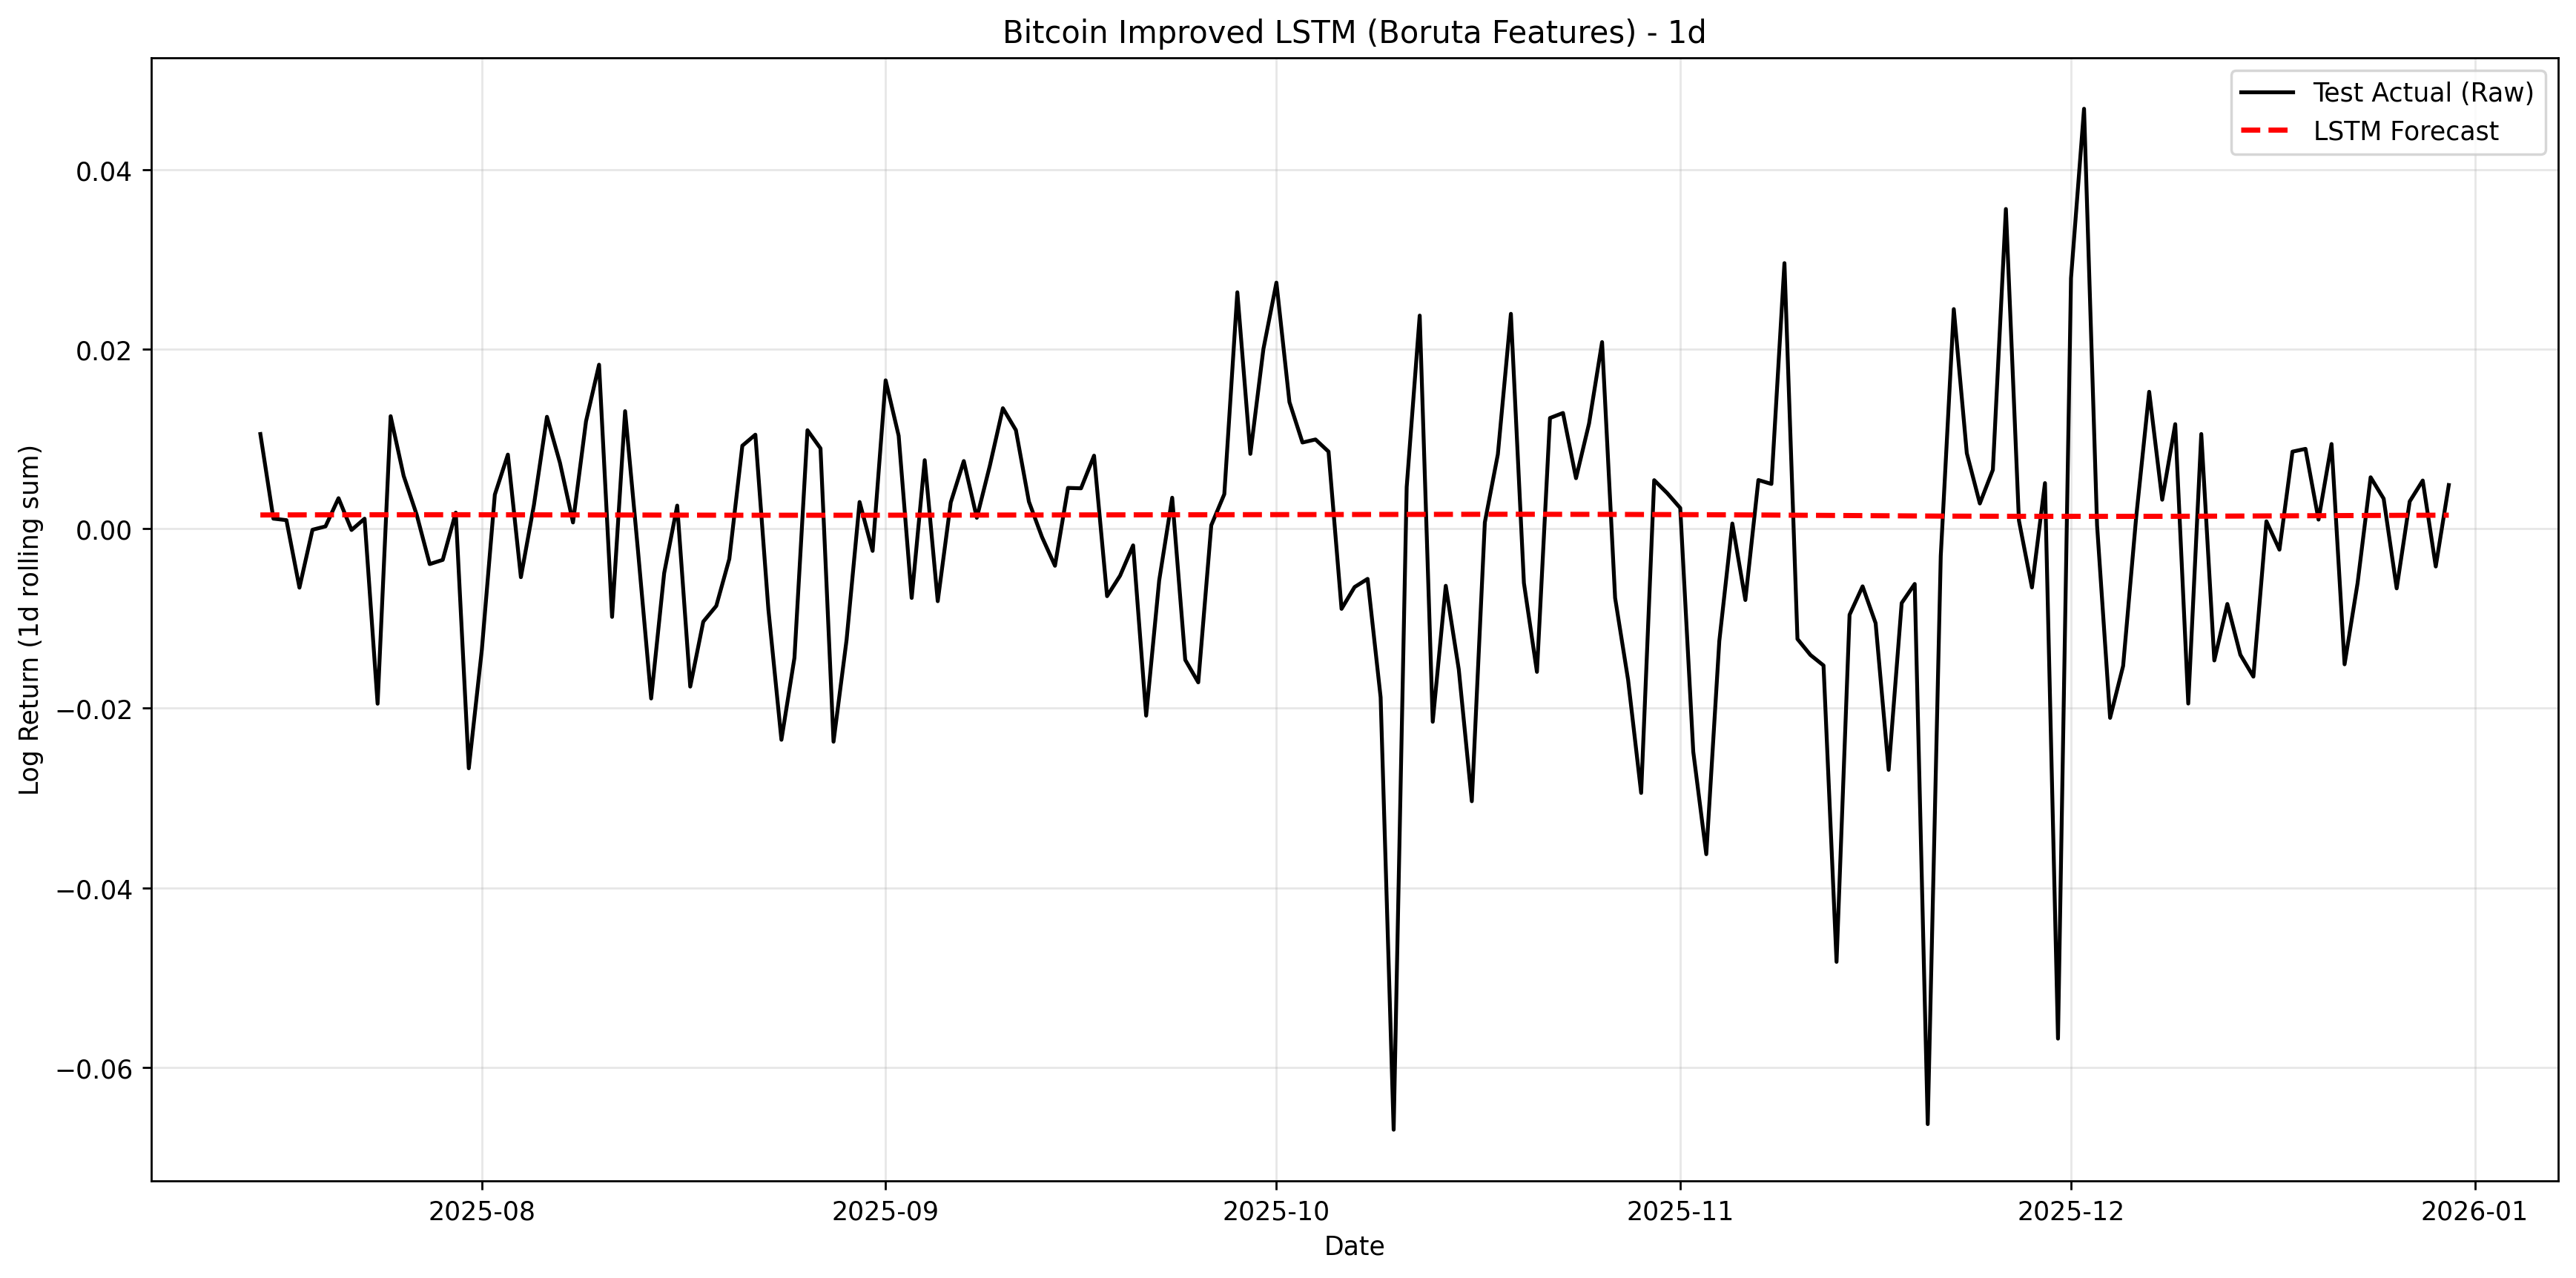


Processing improved Boruta LSTM for 7d
RMSE: 0.059038
MAE:  0.048085
Directional Accuracy: 41.86%


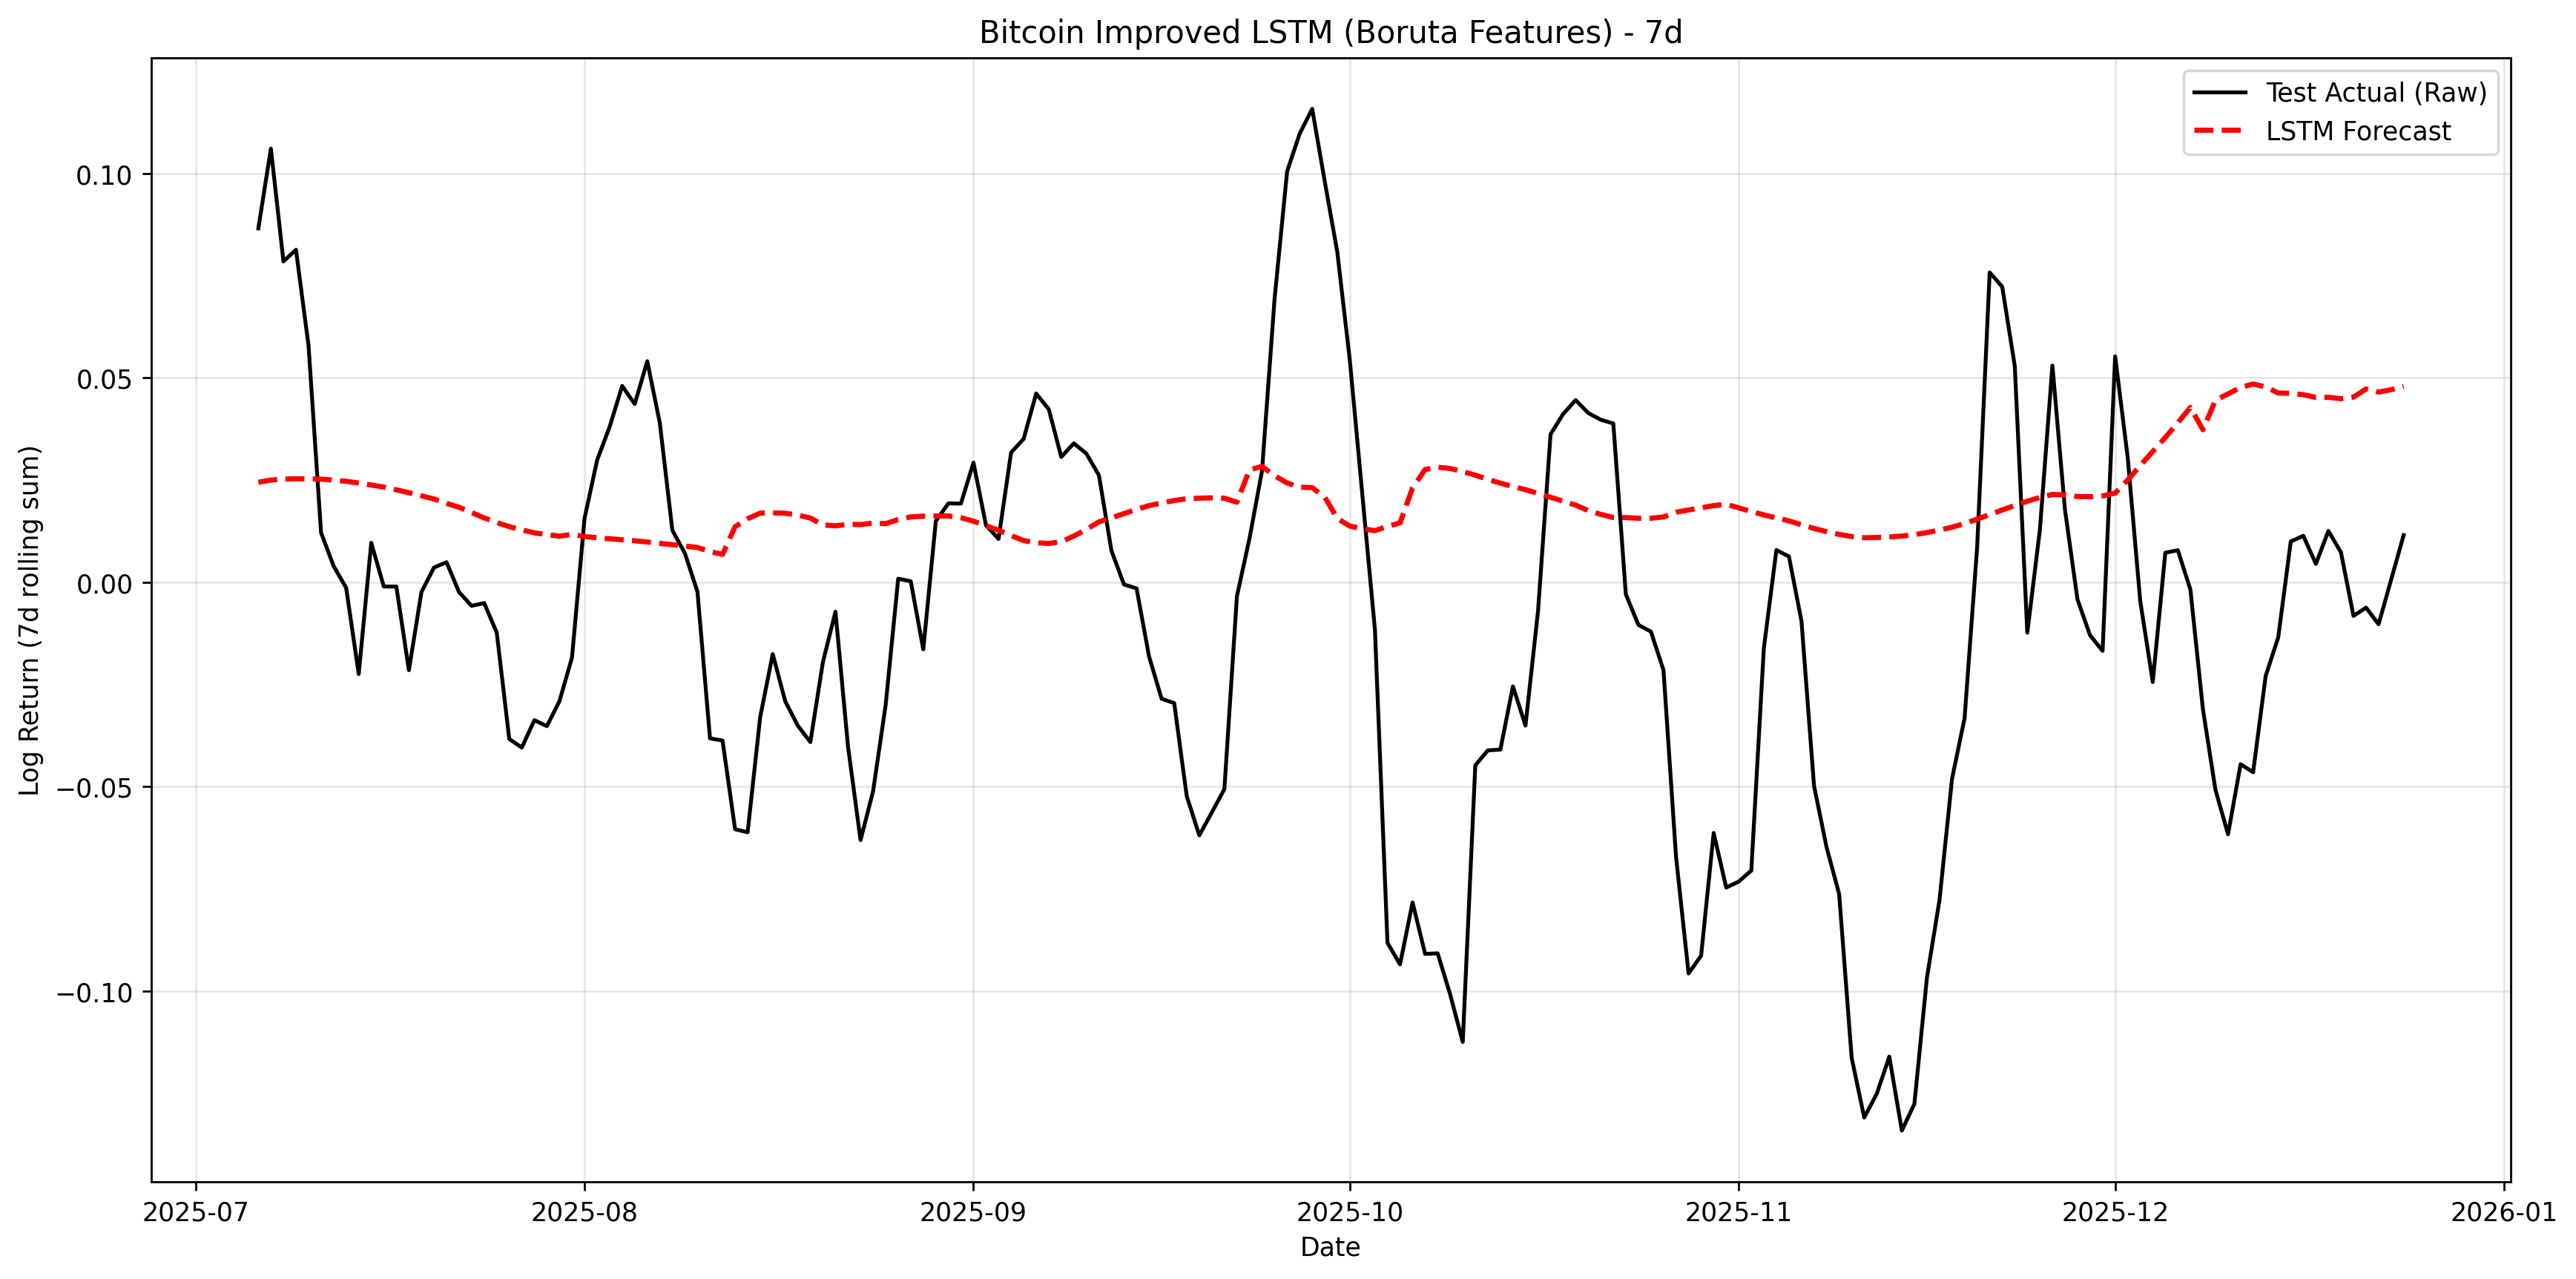


Processing improved Boruta LSTM for 14d
RMSE: 0.087595
MAE:  0.068234
Directional Accuracy: 45.93%


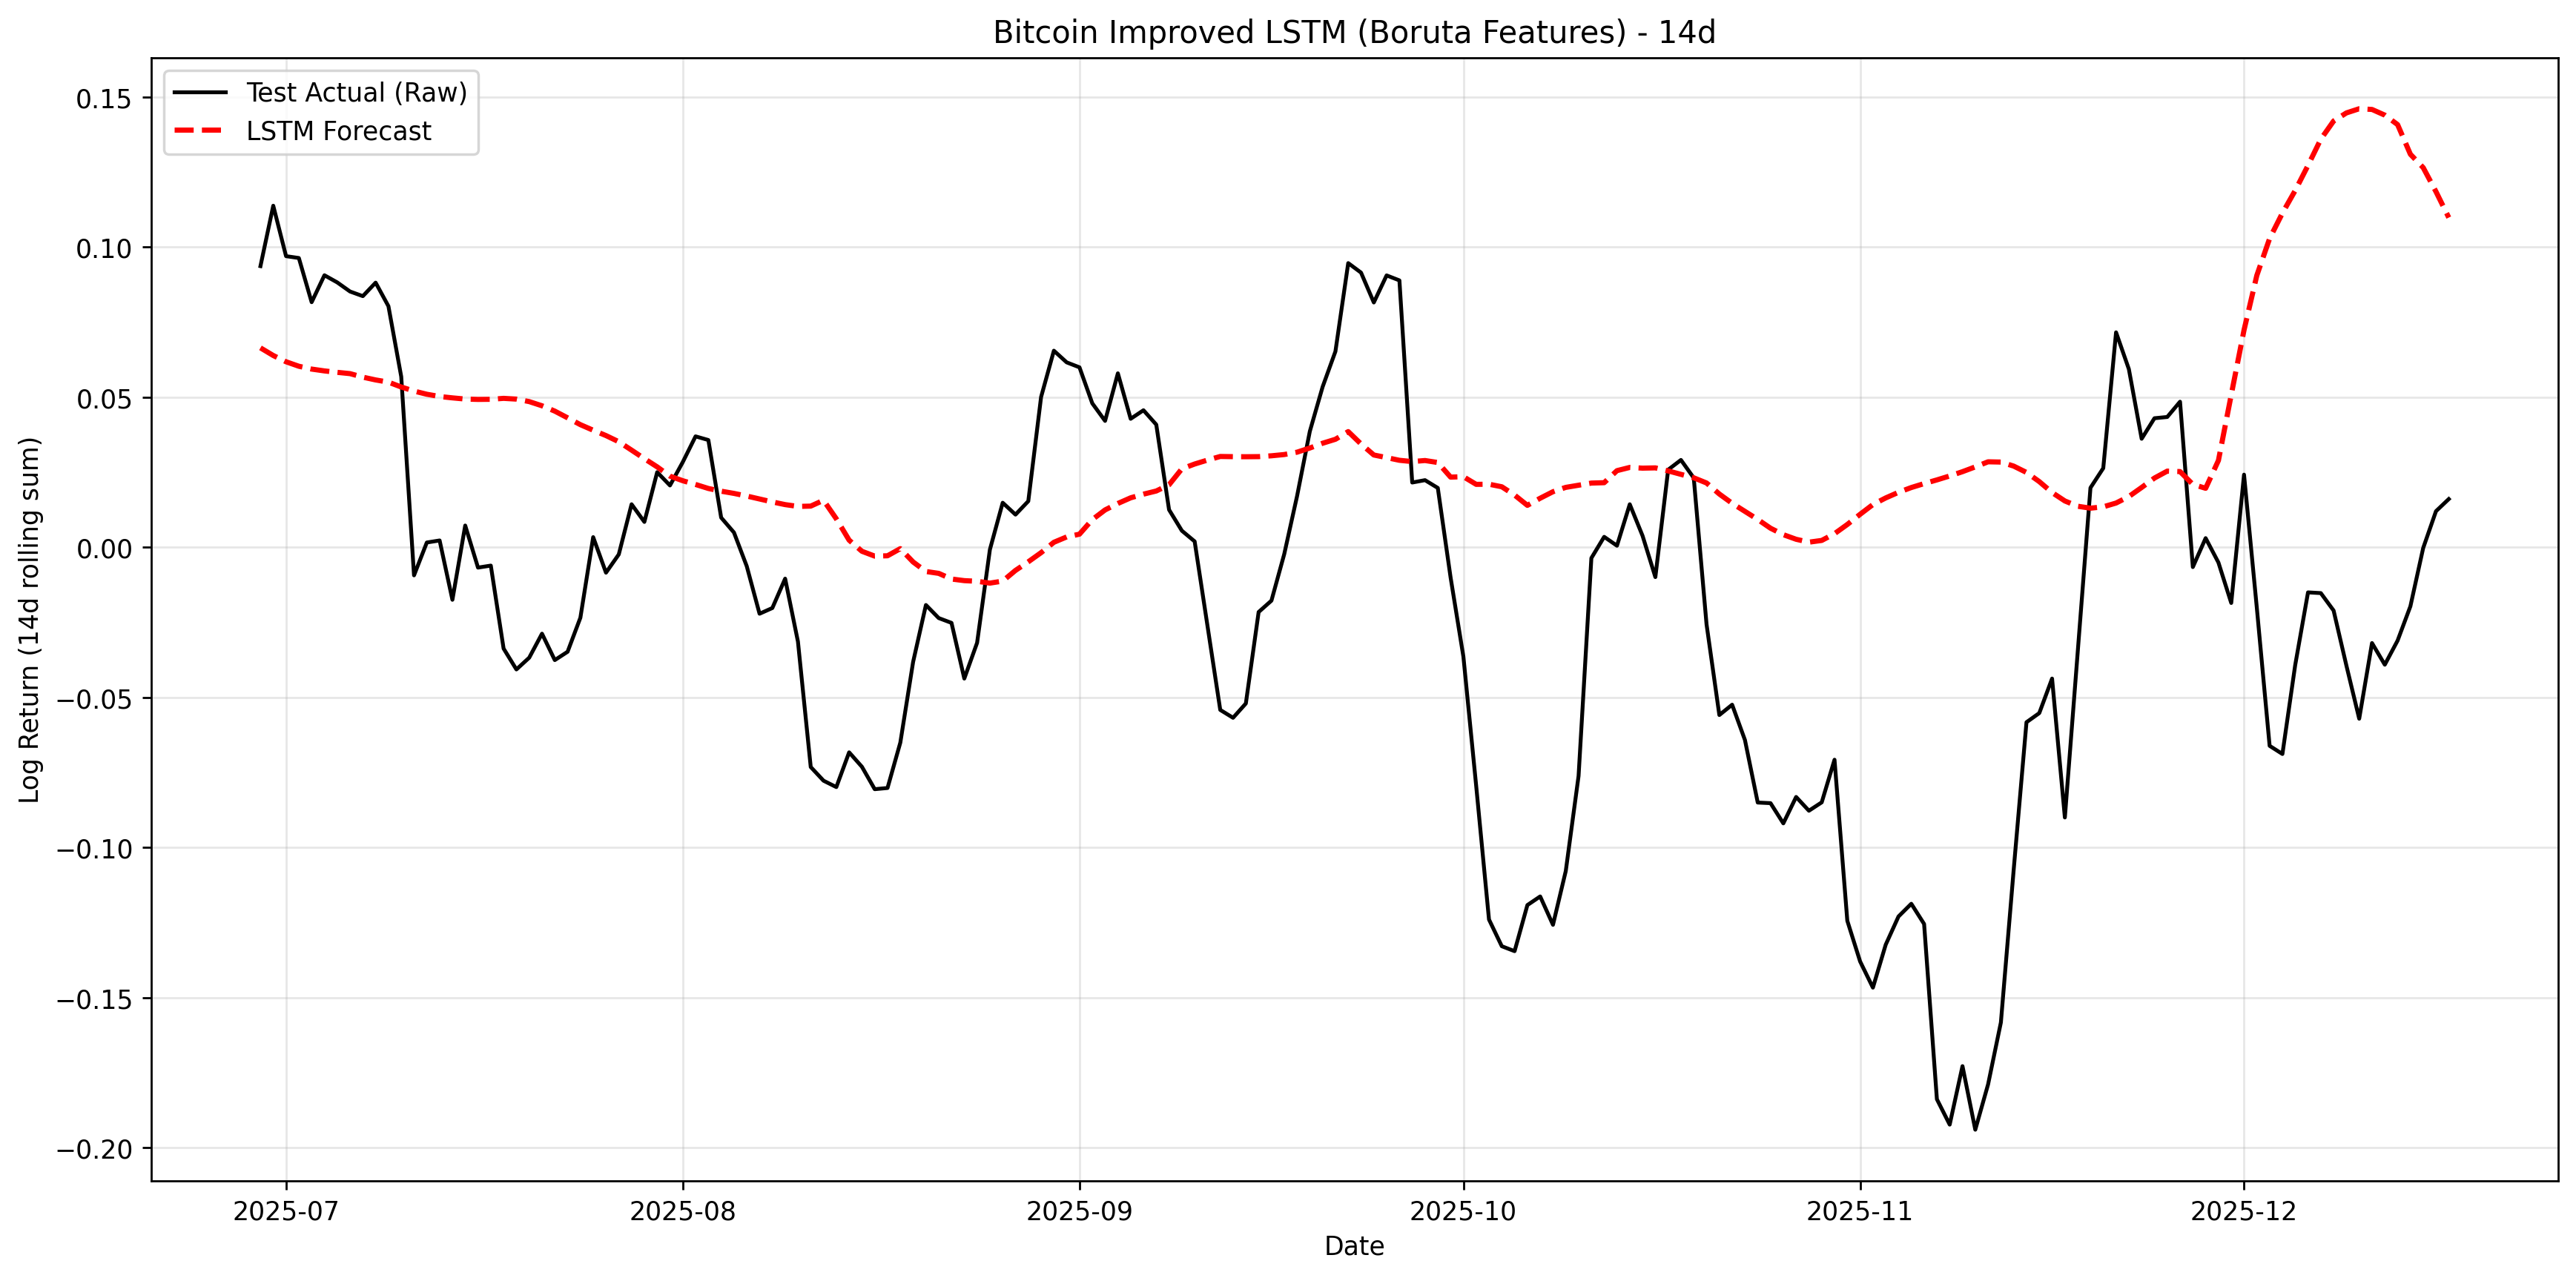


Done: improved Boruta LSTM run completed.


In [ ]:
# @title LSTM MODEL WITH BORUTA
# !pip install tensorflow scikit-learn

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin       = 'bitcoin'
train_end  = '2023-12-31'   # Train: 2016 → 2023 | Test: 2024 → 2025
base_dir   = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
features_dir = os.path.join(base_dir, 'Features Selection/BorutaSelected')
output_dir   = '/content/drive/MyDrive/Crypto Research/RESULTS/LSTM_Boruta'
os.makedirs(output_dir, exist_ok=True)

TIME_STEPS = 14

# ── MAPE helper ──────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ── Sequence generator ────────────────────────────────────────
def create_sequences(X, y, time_steps):
    Xs, ys, indices = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
        indices.append(y.index[i + time_steps])
    return np.array(Xs), np.array(ys), indices

timeframes = [1, 7, 14]

for tf in timeframes:
    print(f"\nProcessing LSTM for Timeframe: {tf}d")

    # ── Load Boruta-selected feature file ─────────────────────
    feat_file = os.path.join(features_dir, f'{coin}_final_boruta_tf{tf}.csv')
    if not os.path.exists(feat_file):
        print(f"Warning: Feature file for {tf}d not found. Skipping.")
        continue

    df_feat = pd.read_csv(feat_file, index_col='Date', parse_dates=True)

    target_col = f'Target_{tf}d'
    feat_cols  = [c for c in df_feat.columns if c != target_col]

    # ── Temporal train / test split ───────────────────────────
    df_train = df_feat.loc[:train_end]
    df_test  = df_feat.loc[train_end:].iloc[1:]

    X_train_raw = df_train[feat_cols]
    y_train_raw = df_train[target_col]
    X_test_raw  = df_test[feat_cols]
    y_test_raw  = df_test[target_col]

    # ── Scale features and target (fit on train only) ─────────
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_sc = pd.DataFrame(scaler_X.fit_transform(X_train_raw),
                              columns=feat_cols, index=X_train_raw.index)
    X_test_sc  = pd.DataFrame(scaler_X.transform(X_test_raw),
                              columns=feat_cols, index=X_test_raw.index)
    y_train_sc = pd.Series(
        scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten(),
        index=y_train_raw.index)
    y_test_sc  = pd.Series(
        scaler_y.transform(y_test_raw.values.reshape(-1, 1)).flatten(),
        index=y_test_raw.index)

    # ── Create 3-D sequences ──────────────────────────────────
    X_tr_seq, y_tr_seq, _  = create_sequences(X_train_sc, y_train_sc, TIME_STEPS)
    X_te_seq, y_te_seq, te_idx = create_sequences(X_test_sc, y_test_sc, TIME_STEPS)

    if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
        print("Not enough data for sequences. Skipping.")
        continue

    # ── Build LSTM ────────────────────────────────────────────
    print("Building and Training LSTM Model...")
    model = Sequential([
        LSTM(50, return_sequences=False,
             input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_tr_seq, y_tr_seq, epochs=100, batch_size=32,
              validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True)],
              verbose=0)

    # ── Forecast & inverse-transform ─────────────────────────
    print("Generating predictions...")
    preds_sc  = model.predict(X_te_seq, verbose=0)
    preds     = scaler_y.inverse_transform(preds_sc).flatten()
    pred_ser  = pd.Series(preds, index=te_idx)
    actual    = y_test_raw.loc[te_idx]

    # ── Metrics (RMSE, MAE, MAPE, R²) ─────────────────────────
    rmse_val = np.sqrt(mean_squared_error(actual, pred_ser))
    mae_val  = mean_absolute_error(actual, pred_ser)
    mape_val = mape(actual, pred_ser)
    r2_val   = r2_score(actual, pred_ser)

    print(f"Evaluation Metrics [{tf}d] — Close Price Regression:")
    print(f"  RMSE : {rmse_val:.4f}")
    print(f"  MAE  : {mae_val:.4f}")
    print(f"  MAPE : {mape_val:.4f} %")
    print(f"  R²   : {r2_val:.4f}")

    # ── Export predictions ────────────────────────────────────
    pd.DataFrame({'Actual_Close_Price': actual,
                  'Predicted_Close_Price': pred_ser}) \
        .to_csv(os.path.join(output_dir, f'{coin}_LSTM_predictions_{tf}d.csv'))

    # ── Plot ──────────────────────────────────────────────────
    plt.figure(figsize=(14, 7), dpi=300)
    plt.plot(actual.index,   actual,   label='Test Actual (Close Price)',
             color='black', linewidth=1.5)
    plt.plot(pred_ser.index, pred_ser, label='LSTM Forecast',
             color='red', linestyle='--', linewidth=2)
    plt.title(f"{coin.capitalize()} LSTM ({tf}d) — Boruta Features\n"
              f"RMSE={rmse_val:.2f} | MAE={mae_val:.2f} | "
              f"MAPE={mape_val:.2f}% | R²={r2_val:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    chart_path = os.path.join(output_dir,
                              f'{coin}_LSTM_forecast_chart_{tf}d.png')
    plt.savefig(chart_path)
    plt.close()
    print(f"Chart saved: {chart_path}")

print("\nMulti-timeframe LSTM (Boruta) complete.")


In [ ]:
# Bi-LSTM Model with Top 10 Boruta Features and Huber Loss
# Target: Close Price regression (2016-2025)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Bidirectional, BatchNormalization)
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin       = 'bitcoin'
train_end  = '2023-12-31'
base_dir   = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
features_dir = os.path.join(base_dir, 'Features Selection/BorutaSelected')
output_dir   = '/content/drive/MyDrive/Crypto Research/RESULTS/LSTM_Boruta_Optimized'
os.makedirs(output_dir, exist_ok=True)

# ── MAPE helper ──────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ── Sequence generator ────────────────────────────────────────
def create_sequences(X, y, time_steps):
    Xs, ys, indices = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
        indices.append(y.index[i + time_steps])
    return np.array(Xs), np.array(ys), indices

# Timeframe → lookback window mapping
timeframes_config = {1: 3, 7: 7, 14: 14}

for timeframe, time_steps in timeframes_config.items():
    print(f"\nProcessing Bi-LSTM for Timeframe: {timeframe}d | Time Steps: {time_steps}")

    feat_file = os.path.join(features_dir,
                             f'{coin}_final_boruta_tf{timeframe}.csv')
    if not os.path.exists(feat_file):
        print(f"Warning: Feature file for {timeframe}d not found. Skipping.")
        continue

    df_feat    = pd.read_csv(feat_file, index_col='Date', parse_dates=True)
    target_col = f'Target_{timeframe}d'
    feat_cols  = [c for c in df_feat.columns if c != target_col]

    # ── Filter top 10 features ────────────────────────────────
    top_k     = min(10, len(feat_cols))
    sel_feats = feat_cols[:top_k]
    print(f"Using top {top_k} features: {sel_feats}")

    # ── Temporal split ────────────────────────────────────────
    df_train = df_feat.loc[:train_end]
    df_test  = df_feat.loc[train_end:].iloc[1:]

    X_train_raw = df_train[sel_feats]
    y_train_raw = df_train[target_col]
    X_test_raw  = df_test[sel_feats]
    y_test_raw  = df_test[target_col]

    # ── Scaling ───────────────────────────────────────────────
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_sc = pd.DataFrame(scaler_X.fit_transform(X_train_raw),
                              columns=sel_feats, index=X_train_raw.index)
    X_test_sc  = pd.DataFrame(scaler_X.transform(X_test_raw),
                              columns=sel_feats, index=X_test_raw.index)
    y_train_sc = pd.Series(
        scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten(),
        index=y_train_raw.index)
    y_test_sc  = pd.Series(
        scaler_y.transform(y_test_raw.values.reshape(-1, 1)).flatten(),
        index=y_test_raw.index)

    # ── Sequences ─────────────────────────────────────────────
    X_tr_seq, y_tr_seq, _      = create_sequences(X_train_sc, y_train_sc, time_steps)
    X_te_seq, y_te_seq, te_idx = create_sequences(X_test_sc,  y_test_sc,  time_steps)

    if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
        print("Not enough data for sequences. Skipping.")
        continue

    # ── Bi-LSTM architecture ──────────────────────────────────
    model = Sequential([
        Bidirectional(LSTM(32, return_sequences=True),
                      input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
        BatchNormalization(), Dropout(0.2),
        Bidirectional(LSTM(16, return_sequences=False)),
        BatchNormalization(), Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss=Huber(delta=1.0))

    print("Training model...")
    history = model.fit(
        X_tr_seq, y_tr_seq, epochs=150, batch_size=32,
        validation_split=0.15,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=25,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=8, min_lr=1e-5)
        ],
        verbose=0
    )
    print(f"Training stopped at epoch: {len(history.history['loss'])}")

    # ── Forecast ─────────────────────────────────────────────
    preds_sc  = model.predict(X_te_seq, verbose=0)
    preds     = scaler_y.inverse_transform(preds_sc).flatten()
    pred_ser  = pd.Series(preds, index=te_idx)
    actual    = y_test_raw.loc[te_idx]

    # ── Metrics (RMSE, MAE, MAPE, R²) ─────────────────────────
    rmse_val = np.sqrt(mean_squared_error(actual, pred_ser))
    mae_val  = mean_absolute_error(actual, pred_ser)
    mape_val = mape(actual, pred_ser)
    r2_val   = r2_score(actual, pred_ser)

    print(f"Evaluation Metrics [{timeframe}d] — Close Price Regression:")
    print(f"  RMSE : {rmse_val:.4f}")
    print(f"  MAE  : {mae_val:.4f}")
    print(f"  MAPE : {mape_val:.4f} %")
    print(f"  R²   : {r2_val:.4f}")

    # ── Export & plot ─────────────────────────────────────────
    pd.DataFrame({'Actual_Close_Price': actual,
                  'Predicted_Close_Price': pred_ser}) \
        .to_csv(os.path.join(output_dir,
                             f'{coin}_BiLSTM_Huber_predictions_{timeframe}d.csv'))

    plt.figure(figsize=(14, 7), dpi=300)
    plt.plot(actual.index,   actual,   label='Test Actual (Close Price)',
             color='black', linewidth=1.5)
    plt.plot(pred_ser.index, pred_ser, label='Bi-LSTM Forecast',
             color='red', linestyle='--', linewidth=2)
    plt.title(f"{coin.capitalize()} Bi-LSTM ({timeframe}d) — Top {top_k} Boruta Features\n"
              f"RMSE={rmse_val:.2f} | MAE={mae_val:.2f} | "
              f"MAPE={mape_val:.2f}% | R²={r2_val:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    chart_path = os.path.join(output_dir,
                              f'{coin}_BiLSTM_Huber_forecast_chart_{timeframe}d.png')
    plt.savefig(chart_path)
    plt.close()

print("\nMulti-timeframe Bi-LSTM complete.")



Processing Bi-LSTM for Timeframe: 1d with Time Steps: 3
Using top 2 features: ['hashrate_7_TRIX', 'sentinusd_14_ROC']
Training model...
Training stopped at epoch: 67
Evaluation Metrics [1d]:
RMSE: 0.016174
MAE:  0.011275
Directional Accuracy: 56.63%


Processing Bi-LSTM for Timeframe: 7d with Time Steps: 7
Using top 10 features: ['transactions_7_STD', 'size_7_SMA', 'size_7_ROC', 'size_14_STD', 'size_14_ROC', 'sentbyaddress_1_ROC', 'sentbyaddress_7_STD', 'sentbyaddress_7_ROC', 'sentbyaddress_7_TRIX', 'sentbyaddress_14_ROC']
Training model...
Training stopped at epoch: 30
Evaluation Metrics [7d]:
RMSE: 0.053967
MAE:  0.041274
Directional Accuracy: 46.24%


Processing Bi-LSTM for Timeframe: 14d with Time Steps: 14
Using top 10 features: ['transactions_14_TRIX', 'size_1_ROC', 'size_7_VAR', 'size_7_ROC', 'size_7_TRIX', 'size_14_SMA', 'size_14_ROC', 'size_14_TRIX', 'sentbyaddress_1_TRIX', 'sentbyaddress_7_ROC']
Training model...
Training stopped at epoch: 28
Evaluation Metrics [14d]:
RMSE: 

In [ ]:
# @title LSTM MODEL WITH RANDOM FOREST REGRESSOR FEATURES
# !pip install tensorflow scikit-learn
# Target: Close Price regression (2016-2025)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────
coin       = 'bitcoin'
train_end  = '2023-12-31'
base_dir   = '/content/drive/MyDrive/Crypto Research/DATA/Technical Indicators'
features_dir = os.path.join(base_dir, 'Features Selection/RandomForestRegressorSelected')
output_dir   = '/content/drive/MyDrive/Crypto Research/RESULTS/LSTM_RandomForestFeatures'
os.makedirs(output_dir, exist_ok=True)

TIME_STEPS = 14

# ── MAPE helper ──────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ── Sequence generator ────────────────────────────────────────
def create_sequences(X, y, time_steps):
    Xs, ys, indices = [], [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
        indices.append(y.index[i + time_steps])
    return np.array(Xs), np.array(ys), indices

timeframes = [1, 7, 14]

for tf in timeframes:
    print(f"\nProcessing LSTM for Timeframe: {tf}d using Random Forest Features")

    feat_file = os.path.join(features_dir, f'{coin}_final_tf{tf}.csv')
    if not os.path.exists(feat_file):
        print(f"Warning: Feature file for {tf}d not found. Skipping.")
        continue

    df_feat    = pd.read_csv(feat_file, index_col='Date', parse_dates=True)
    target_col = f'Target_{tf}d'
    feat_cols  = [c for c in df_feat.columns if c != target_col]

    # ── Temporal split ────────────────────────────────────────
    df_train = df_feat.loc[:train_end]
    df_test  = df_feat.loc[train_end:].iloc[1:]

    X_train_raw = df_train[feat_cols]
    y_train_raw = df_train[target_col]
    X_test_raw  = df_test[feat_cols]
    y_test_raw  = df_test[target_col]

    # ── Scale features and target (fit on train only) ─────────
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_sc = pd.DataFrame(scaler_X.fit_transform(X_train_raw),
                              columns=feat_cols, index=X_train_raw.index)
    X_test_sc  = pd.DataFrame(scaler_X.transform(X_test_raw),
                              columns=feat_cols, index=X_test_raw.index)
    y_train_sc = pd.Series(
        scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten(),
        index=y_train_raw.index)
    y_test_sc  = pd.Series(
        scaler_y.transform(y_test_raw.values.reshape(-1, 1)).flatten(),
        index=y_test_raw.index)

    # ── Create 3-D sequences ──────────────────────────────────
    X_tr_seq, y_tr_seq, _      = create_sequences(X_train_sc, y_train_sc, TIME_STEPS)
    X_te_seq, y_te_seq, te_idx = create_sequences(X_test_sc,  y_test_sc,  TIME_STEPS)

    if len(X_tr_seq) == 0 or len(X_te_seq) == 0:
        print("Not enough data for sequences. Skipping.")
        continue

    # ── Build LSTM ────────────────────────────────────────────
    print("Building and Training LSTM Model...")
    model = Sequential([
        LSTM(50, return_sequences=False,
             input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_tr_seq, y_tr_seq, epochs=100, batch_size=32,
              validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True)],
              verbose=0)

    # ── Forecast & inverse-transform ─────────────────────────
    print("Generating predictions...")
    preds_sc  = model.predict(X_te_seq, verbose=0)
    preds     = scaler_y.inverse_transform(preds_sc).flatten()
    pred_ser  = pd.Series(preds, index=te_idx)
    actual    = y_test_raw.loc[te_idx]

    # ── Metrics (RMSE, MAE, MAPE, R²) ─────────────────────────
    rmse_val = np.sqrt(mean_squared_error(actual, pred_ser))
    mae_val  = mean_absolute_error(actual, pred_ser)
    mape_val = mape(actual, pred_ser)
    r2_val   = r2_score(actual, pred_ser)

    print(f"Evaluation Metrics [{tf}d] — Close Price Regression:")
    print(f"  RMSE : {rmse_val:.4f}")
    print(f"  MAE  : {mae_val:.4f}")
    print(f"  MAPE : {mape_val:.4f} %")
    print(f"  R²   : {r2_val:.4f}")

    # ── Export predictions ────────────────────────────────────
    pd.DataFrame({'Actual_Close_Price': actual,
                  'Predicted_Close_Price': pred_ser}) \
        .to_csv(os.path.join(output_dir, f'{coin}_LSTM_RF_predictions_{tf}d.csv'))

    # ── Plot ──────────────────────────────────────────────────
    plt.figure(figsize=(14, 7), dpi=300)
    plt.plot(actual.index,   actual,   label='Test Actual (Close Price)',
             color='black', linewidth=1.5)
    plt.plot(pred_ser.index, pred_ser, label='LSTM Forecast',
             color='red', linestyle='--', linewidth=2)
    plt.title(f"{coin.capitalize()} LSTM ({tf}d) — RF Features\n"
              f"RMSE={rmse_val:.2f} | MAE={mae_val:.2f} | "
              f"MAPE={mape_val:.2f}% | R²={r2_val:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Close Price (USD)")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    chart_path = os.path.join(output_dir,
                              f'{coin}_LSTM_RF_forecast_chart_{tf}d.png')
    plt.savefig(chart_path)
    plt.close()
    print(f"Chart saved: {chart_path}")

print("\nMulti-timeframe LSTM (RF Features) complete.")



Processing LSTM for Timeframe: 1d using Random Forest Features
Building and Training LSTM Model...
Generating predictions...
Evaluation Metrics [1d]:
RMSE: 0.016296
MAE:  0.011432
Directional Accuracy: 54.59%

Chart saved to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/RESULTS/LSTM_RandomForestFeatures/bitcoin_LSTM_RF_forecast_chart_1d.png

Processing LSTM for Timeframe: 7d using Random Forest Features
Building and Training LSTM Model...
Generating predictions...
Evaluation Metrics [7d]:
RMSE: 0.090959
MAE:  0.070250
Directional Accuracy: 49.72%

Chart saved to: /content/drive/MyDrive/Crypto Research/DATA/Technical Indicators/RESULTS/LSTM_RandomForestFeatures/bitcoin_LSTM_RF_forecast_chart_7d.png

Processing LSTM for Timeframe: 14d using Random Forest Features
Building and Training LSTM Model...
Generating predictions...
Evaluation Metrics [14d]:
RMSE: 0.102921
MAE:  0.081074
Directional Accuracy: 42.44%

Chart saved to: /content/drive/MyDrive/Crypto Research/DATA